<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/Project_Food_Hub_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Food Hub Analysis**

## **Context :**

**The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.**

**The app allows restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin on the delivery order from the restaurants.**

## **Objective :**

**The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.**

## **Problem Statement:**

**Analyze the dataset to uncover ordering patterns, customer preferences, delivery performance, and revenue opportunities in order to support business decisions and enhance customer experience.**

### **Data Dictionary**

* **order_id:** Unique ID of the order

* **customer_id:** ID of the customer who ordered the food

* **restaurant_name:** Name of the restaurant

* **cuisine_type:** Cuisine ordered by the customer

* **cost_of_the_order:** Cost of the order

* **day_of_the_week:** Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)

* **rating:** Rating given by the customer out of 5
food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.

* **delivery_time:** Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

**Importing Some required libraries**

In [ ]:
# Importing all the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.2f}'.format
from IPython.display import display

In [ ]:
# Connecting Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# data loading
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/Project/foodhub_order.csv')
  print("Data Loaded successfully 🚀")
except Exception as a :
  print("Not found!")
  print(a)

Data Loaded successfully 🚀


In [ ]:
# Making copy of original dataset ( good practice to work on copy data not on original data)
df = data.copy()

In [ ]:
# checking 1st five rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
# checking 5 last rows

df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


In [ ]:
# checking the table shape
df.shape

(1898, 9)

In [ ]:
# Quick overview of the data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


**Observations (Data Overview):**

*   In this table there are 9 columns & 1898 rows.
*   There are 0 null values.
*   Table contains 3 different data type's which is float, int, object.
*   Total 4 columns are Categorical & 5 columns are Numerical.

### **Q1. How many rows & columns are present in the data ?**

In [ ]:
rows, columns = df.shape
print(f"There are total {columns} Columns & total {rows} Rows")

There are total 9 Columns & total 1898 Rows


### **Q2. What are the datatypes of the different columns in the dataset?**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


**Observations :**

* In this table there are 9 column, out of that 4 columns were categorical (object) & 5 columns were numerical (int & Float)

* Here "rating" column is in object datatype but it should be in "int" format Then only we can able to find the min, max, avg rating per restaurant.

* The rating column is in object format because of that column has two types of value one is Number & other is string which is "Not given".

### **Q3. Are there any missing values in the data? If yes, treat them using an appropriate method.**

In [ ]:
df.isnull().sum().reset_index()

,index,0
0,order_id,0
1,customer_id,0
2,restaurant_name,0
3,cuisine_type,0
4,cost_of_the_order,0
5,day_of_the_week,0
6,rating,0
7,food_preparation_time,0
8,delivery_time,0


**Observations :**

* As observed, the dataset does not contain any missing values.

### **Q4. Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?**

In [ ]:
# Statistics of only numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


**Observations :**     

* From the above statistical summary, the columns Order ID and Customer ID are numeric (integer type), but they do not offer any significant statistical information for analysis.

* we have three more importan column which is "cost_of_the_order", "food_preparation_time" & "delivery_time".

* As per the summary there are total 1898 orders.

-------------------------------------

**[1] Column : "Cost of the Order"**

* The minimum order cost has 4.47 dollars & maximum order cost goes till 35.41 dollars, average order cost is around 16.49.

* 25% of Orders cost below <=12 dollars & 75% of the orders cost below <= 22 dollars & most expensive orders cost is goes around 35.41 dollars.

* here std is 7.48 & Mean is 16.49, if we do calculation like std / mean ( 7.48 / 16.49 ) we get std. is about 0.45 of mean.

* comparision between the std & Mean the variation is 0.44 which is the betwen 0.3 - 0.6 so, variation is "Moderate variation".

* AOV is around 16.49, so roughly order cost goes (mean ± std) around 9 to 24.
( 16.49 + 7.48 = 24 & 16.49 - 7.48 = 9 )

* **Conclusion :** So, The Std.(7.48) is about 45% of the mean ( 16.49 ), indicating a **High level of variability in order cost.**

-------------------

**[2] Column : "Food Prepration Time"**

* The food prepration time is considered from once order get confirmed by resturant.

* The **Minimum food prep. time is 25 min**., **max time around 35 Min**. &  **Average prep. time around 27.37 min**.

* Here std. is 4.63 min. & mean (avg. time) is 27.37 if we find the variation% will get the 0.17  std. about the mean. So variation is "low Variation"

* Avg. time for food prepration takes 27.37 min., roughly food prep. time will takes between ( mean ± std ) around 23 - 32 min.         
[ 27.37 - 4.63 = 23 &  27.37 + 4.63 = 32]

* **Conclusion :** So, The std.(4.3) is about 17% of the mean(27.27), indicating a **Moderate level of veriability in food prepration time.**

--------------------------------

[3] **column : "Delivery Time"**

* The order delivery time is considered from order is packed & picked up by delivery partner to order delivered to the customer.

* The Minimum delivery time 15 min., maximum order delivery time is 33 min. & average delivery time is around 24.16 min.

* Here, avg. delivery time is slightly less than avg. food prep. time.

* standared deviation of delivery time is 4.97 min. & mean is 24.16 min. if we find the variation, will get variation around 0.21 So, this is low level of variation in delivery time.

* So, Camparision between the std. & mean is 0.21. roughly food delivery time is between 19 - 29 min.
[ 24.16 - 4.97 = 19 & 24.16 + 4.97 = 29 ]

* **Conclusion :** So, The Std(4.97) is about the 21% of the mean(24.16), Indicating **"Moderate level of veriability in food delivery time"**

### **Q5. How many orders are not rated?**

In [ ]:
df['rating'].value_counts().reset_index()

,rating,count
0,Not given,736
1,5,588
2,4,386
3,3,188


In [ ]:
not_rated_orders = (df['rating']== 'Not given').sum()
print(f'There are {not_rated_orders} orders in the table that were not rated.')

There are 736 orders in the table that were not rated.


**Observations :**    

* There are a total of **1898** rows in this table.

* In the rating column, there are four unique values, and the value **'Not given'** indicates orders that have not been rated.

* The total number of **unrated orders is 736.**

# **Exploratory Data Analysis (EDA)**

## **Univariate Analysis**

#### **Q6. Explore all the variables and provide observations on their distributions.**

In [ ]:
(df['order_id'].value_counts() > 1).sum()

np.int64(0)

**Observations :**

* In column order ID there is no any duplicate order id all are unique

**_________________________________________________________________________________**

In [ ]:
top_10_customers = df['customer_id'].value_counts().head(10).reset_index()
print("Top 10 Customers")
display(top_10_customers)

print()  # used to print some gap between two table

print("Bottom 10 Customers")
bottom_10_customers = df['customer_id'].value_counts().tail(10).reset_index()
display(bottom_10_customers)

Top 10 Customers


,customer_id,count
0,52832,13
1,47440,10
2,83287,9
3,250494,8
4,259341,7
5,65009,7
6,276192,7
7,82041,7
8,115213,6
9,60052,6



Bottom 10 Customers


,customer_id,count
0,100889,1
1,111894,1
2,68834,1
3,66222,1
4,221206,1
5,143926,1
6,89574,1
7,157711,1
8,66393,1
9,358141,1


**Observations :**

* 1st table shows top 10 customers who ordered multiple time.
* 2nd table shows bottom 10 customers who have purchased only 1 order.


**_________________________________________________________________________________**

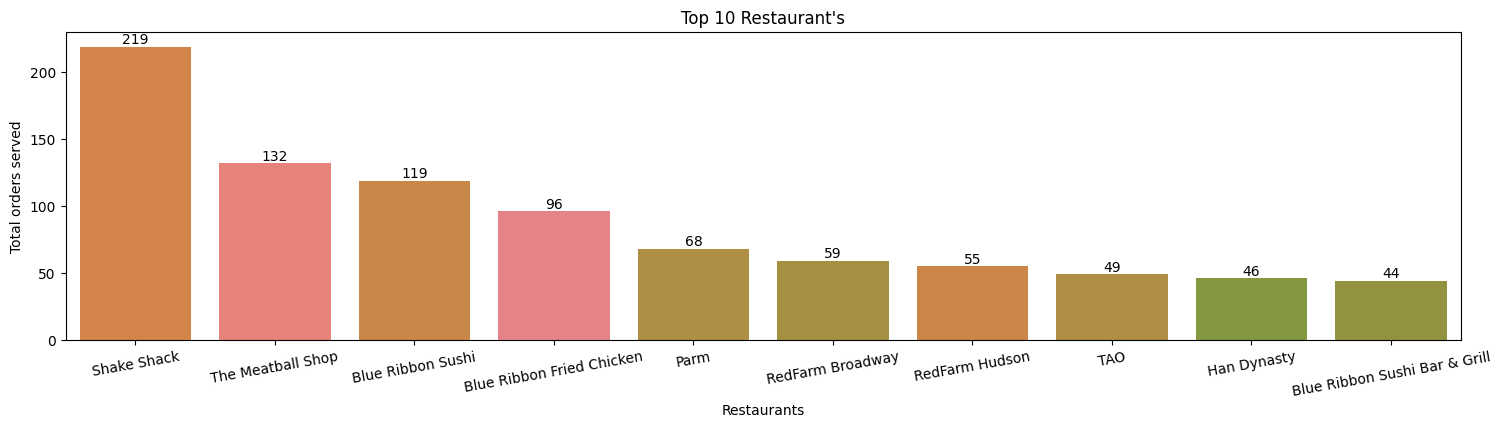

In [ ]:
# Top 10 Restaurants

plt.figure(figsize= (18, 4))
plt.title("Top 10 Restaurant's")
plot_1 = sns.countplot(data=df, x = 'restaurant_name', order = df['restaurant_name'].value_counts().head(10).index, hue = 'restaurant_name' )
plt.xticks(rotation = 10)
plt.xlabel('Restaurants')
plt.ylabel('Total orders served')

# below line of code is used to place a values on bar.
for value in plot_1.containers:
    plot_1.bar_label(value)

plt.show()

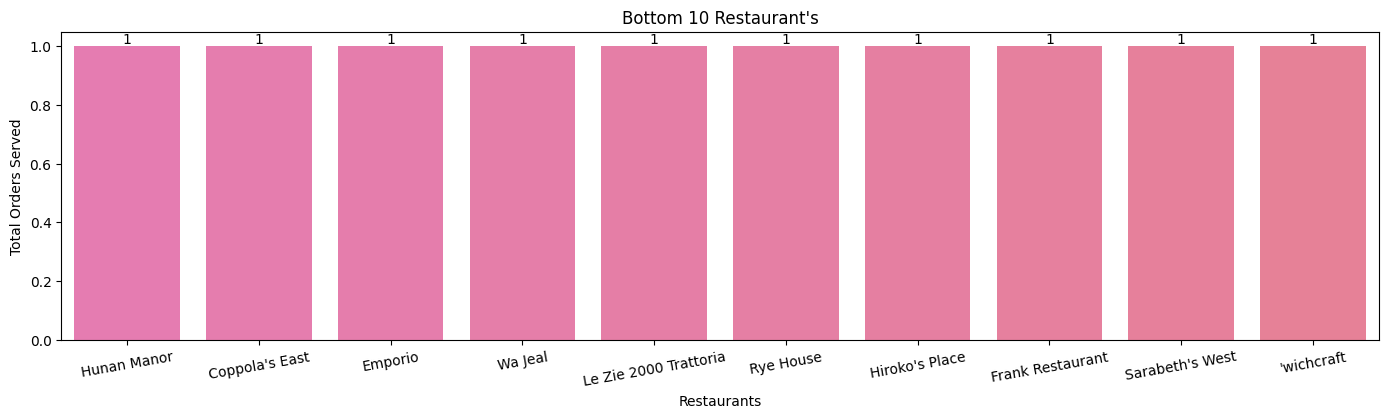

In [ ]:
# bottom 10 restaurants

plt.figure(figsize = (17, 4))
plt.title("Bottom 10 Restaurant's")
plot_2 = sns.countplot(data=df, x = 'restaurant_name', order = df['restaurant_name'].value_counts().tail(10).index, hue = 'restaurant_name')
plt.xticks(rotation=10)
plt.xlabel('Restaurants')
plt.ylabel("Total Orders Served")

for value in plot_2.containers :
  plot_2.bar_label(value)

plt.show()

**Observation's :**

* From Plot 1, we can clearly observe the top 10 restaurants that serve the highest number of orders. “Shake Shack” holds the top position among all restaurants, followed by “The Meatball Shop” in second place.

* From Plot 2, we can observe the restaurants that are at the bottom in terms of the number of orders served.

* In plot 2 we can see only those restaurant's whoes recivies only one orders.

**__________________________________________________________________________________**

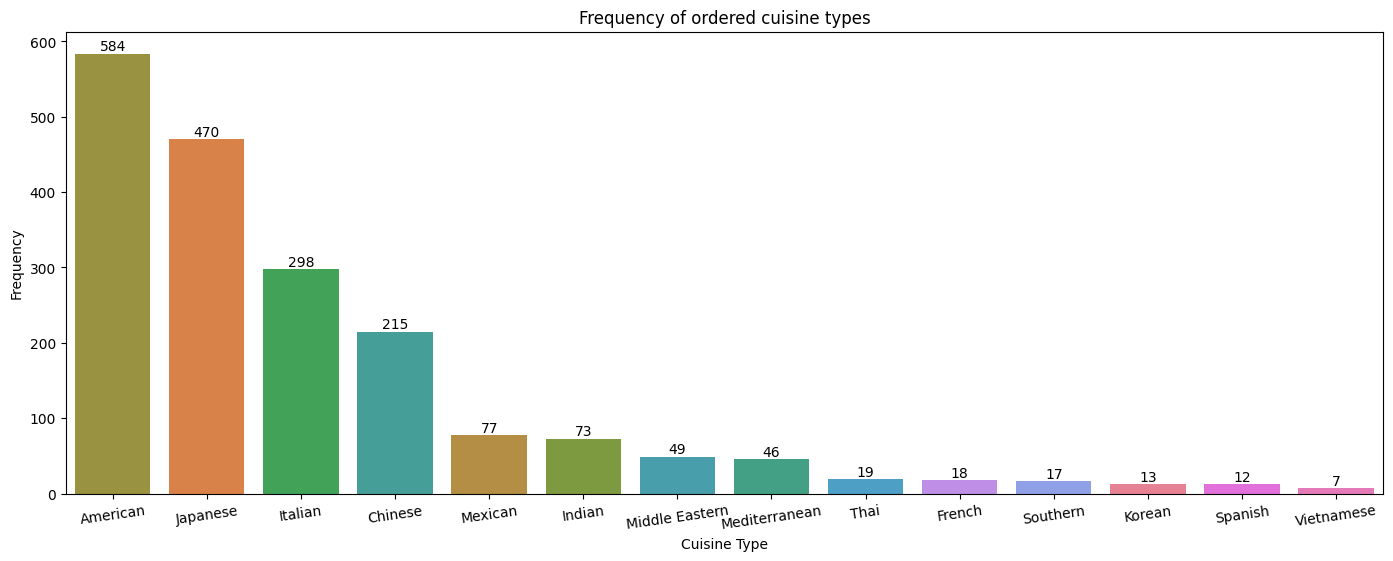

In [ ]:
# defining plot size width & hight
plt.figure(figsize = (17, 6))
# title of chart
plt.title('Frequency of ordered cuisine types')

plot_3 = sns.countplot(data=df, x = 'cuisine_type', order = df['cuisine_type'].value_counts().index ,hue = 'cuisine_type')
plt.xlabel('Cuisine Type')
plt.ylabel('Frequency')
plt.xticks(rotation = 8)

for values in plot_3.containers :
  plot_3.bar_label(values)

plt.show()



**Observation's :**

* The graph clearly shows that the most **frequently ordered cuisines** are American, Japanese, Italian, and Chinese, indicating that customers strongly prefer food from these categories.

* Mexican, Indian, and Middle Eastern–Mediterranean **cuisines have relatively similar order frequencies**, with only slight variations among them.

* Cuisines such as Thai, French, Southern, Korean, Spanish, and Vietnamese receive fewer orders. Among these, Vietnamese cuisine has the lowest number of orders and ranks at the bottom in terms of customer preference.

**__________________________________________________________________________________**

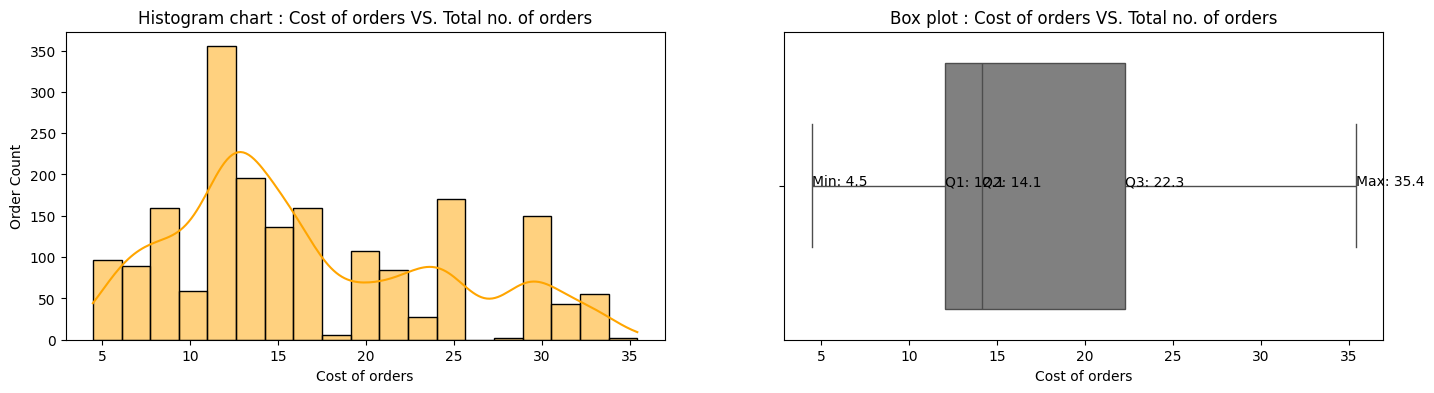

In [ ]:
plt.figure(figsize = (17, 4))

plt.subplot(1,2,1)
plt.title( 'Histogram chart : Cost of orders VS. Total no. of orders')
sns.histplot(data=df, x = 'cost_of_the_order', kde = True, color= 'orange')
plt.xlabel('Cost of orders')
plt.ylabel('Order Count')


plt.subplot(1,2,2)
plt.title('Box plot : Cost of orders VS. Total no. of orders')
sns.boxplot(data=df, x = 'cost_of_the_order', color= 'gray')
plt.xlabel('Cost of orders')

stats1 = df['cost_of_the_order'].describe()

plt.text(stats1['min'], 0, f"Min: {stats1['min']:.1f}")
plt.text(stats1['25%'], 0, f"Q1: {stats1['25%']:.1f}")
plt.text(stats1['50%'], 0, f"Q2: {stats1['50%']:.1f}")
plt.text(stats1['75%'], 0, f"Q3: {stats1['75%']:.1f}")
plt.text(stats1['max'], 0, f"Max: {stats1['max']:.1f}")


plt.show()

**Observation's :**   

* From above histogram plot we can see, most of the time food ordered in 9 - 19 dollar price range. its showing pick. ( This price range is more than other price range).

* Customers prefered food with affordable price.

* from Box Plot we can easly see, the minimum food cost starts from 5 dollars & most expensive food cost around 35.

* 25% of food cost is below 14 dollar. 50% of the food cost is below 15 dollars & 50% food cost is above 15 dollars.

* 75% of orders cost are below 23 dollars. no outliers are detecting here.

* **Final Conclusion :** median order cost is 14 dollar, 50% of orders cost in range between 12 - 23 dollars. & the order cost ranges between the 5 - 35 dollars. no outliers are detected.

* This both plot is positive (Right Skewed) skewed. most of the data frequency present in right side.  


**__________________________________________________________________________________**

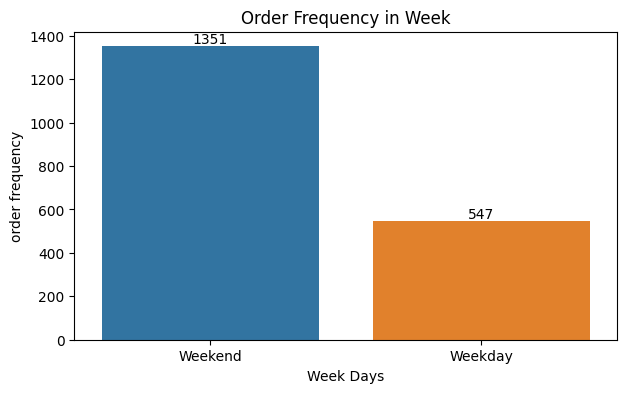

In [ ]:
plt.figure(figsize = (7, 4))
plt.title('Order Frequency in Week')
plot_4 = sns.countplot(data=df, x = 'day_of_the_week', hue = 'day_of_the_week')
plt.xlabel('Week Days')
plt.ylabel('order frequency')

for value in plot_4.containers :
    plot_4.bar_label(value)

plt.show()

**Observation's :**    

* Food orders are more frequent on weekends compared to weekdays.

**__________________________________________________________________________________**

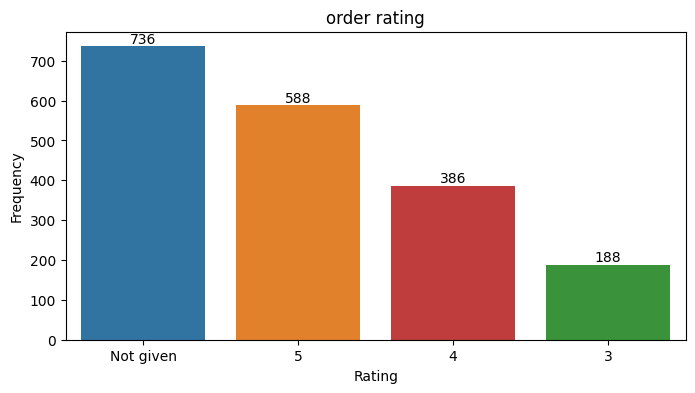

In [ ]:
plt.figure(figsize = (8,4))
plt.title('order rating')
plot_5 = sns.countplot(data=df, x = 'rating', order = df['rating'].value_counts().index, hue = 'rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')

for value in plot_5.containers :
  plot_5.bar_label(value)

plt.show()

**Observation's :**    

* From the analysis, we can observe that 736 out of 1,898 orders do not have ratings, which accounts for approximately **38%** of the total orders.

* Although customers are placing orders, many of them are not providing ratings. This could be because customers forget to rate their orders or intentionally choose not to provide feedback, possibly due to delivery issues or dissatisfaction with food quality.

**__________________________________________________________________________________**

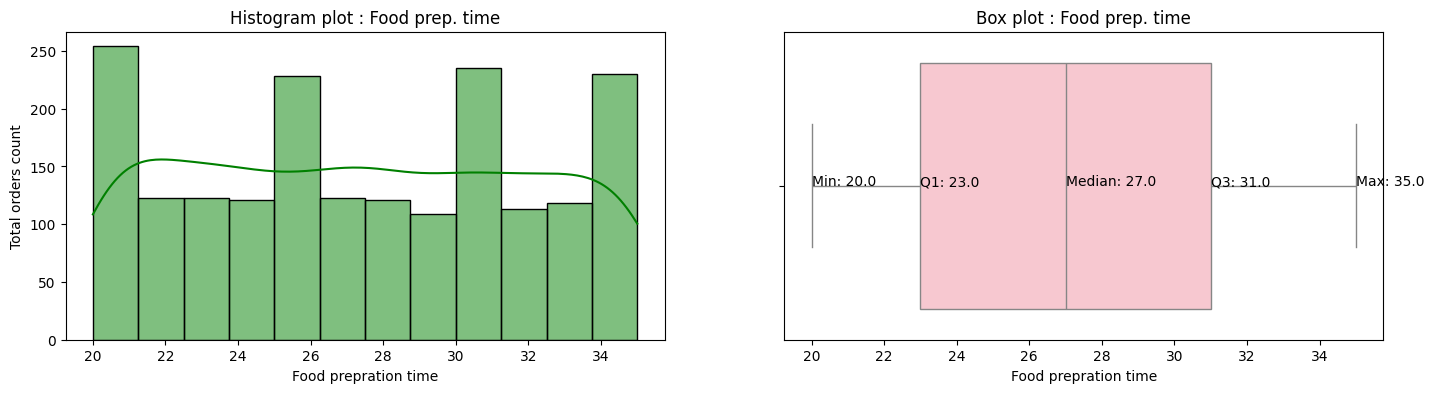

In [ ]:
plt.figure(figsize = (17, 4))

plt.subplot(1,2,1)
plt.title('Histogram plot : Food prep. time')
sns.histplot(data=df, x = 'food_preparation_time', kde = True, color= 'green')
plt.xlabel('Food prepration time')
plt.ylabel('Total orders count')

plt.subplot(1,2,2)
plt.title('Box plot : Food prep. time')
sns.boxplot(data=df, x = 'food_preparation_time', color= 'pink')
plt.xlabel('Food prepration time')

# ploting the values on box plot
stats = df['food_preparation_time'].describe()

plt.text(stats['min'], 0, f"Min: {stats['min']:.1f}")
plt.text(stats['25%'], 0, f"Q1: {stats['25%']:.1f}")
plt.text(stats['50%'], 0, f"Median: {stats['50%']:.1f}")
plt.text(stats['75%'], 0, f"Q3: {stats['75%']:.1f}")
plt.text(stats['max'], 0, f"Max: {stats['max']:.1f}")

plt.show()

**Observation's :**

* Most frequent orders are takes time between 23-31 min. in both the plot's ( Histogram & boxplot )

* We can clearly see, the Kde line is symmetric from both the sides in Histogram plot.

* In boxplot we can see min. food prepration time 20 min. & max side it goes around 35 min. There is no skew.

* 50% of orders tooks 23-31 min. & 75% of food takes food prep. time below 31 min., once order get confirmed.

**__________________________________________________________________________________**

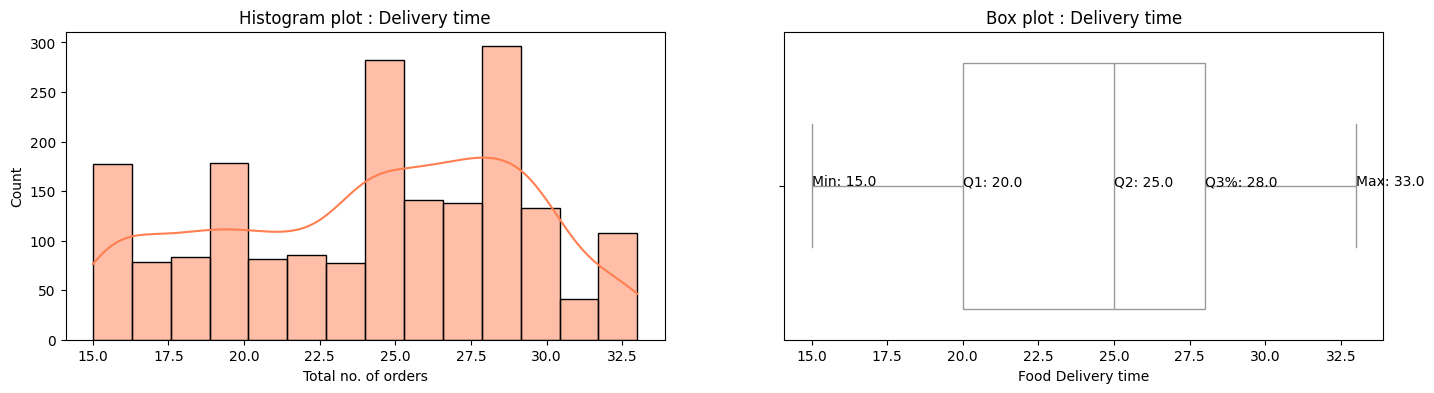

In [ ]:
plt.figure(figsize = (17,4))

plt.subplot(1,2,1)
plt.title('Histogram plot : Delivery time')
sns.histplot(data=df, x = 'delivery_time', kde= True, color = 'coral')
plt.xlabel('Food Delivery time')
plt.xlabel('Total no. of orders')

plt.subplot(1,2,2)
plt.title('Box plot : Delivery time')
sns.boxplot(data=df, x = 'delivery_time', color= 'white')
plt.xlabel('Food Delivery time')


stats = df['delivery_time'].describe()
plt.text(stats['min'], 0, f"Min: {stats['min']:.1f}")
plt.text(stats['25%'], 0, f"Q1: {stats['25%']:.1f}")
plt.text(stats['50%'], 0, f"Q2: {stats['50%']:.1f}")
plt.text(stats['75%'], 0, f"Q3%: {stats['75%']:.1f}")
plt.text(stats['max'], 0, f"Max: {stats['max']:.1f}")

plt.show()


**Observation's :**    

* As we can see, in above both the graph data is slightly in left side so its indicating left side skewed.

* Most of the time orders has delivered between 20 - 28 min.

* Minimum time to food delivery takes 15 min. & max side it goes around the 33 min.

* 25% of orders are delivered <= 20 min., 50% of orders delivered <= 25 min., & 75% of orders are delivered <= 28 min. & max side delivery takes 33 min.

* No outliers are found in data so data is more consistent.

**__________________________________________________________________________________**

#### **Q7. Which are the top 5 restaurants in terms of the number of orders received?**

In [ ]:
df['restaurant_name'].value_counts().head(5).reset_index()

,restaurant_name,count
0,Shake Shack,219
1,The Meatball Shop,132
2,Blue Ribbon Sushi,119
3,Blue Ribbon Fried Chicken,96
4,Parm,68


**Observation's :**

* This all are the top 5 restaurants whoes recived high orders.

#### **Q8. Which is the most popular cuisine on weekends?**

In [ ]:
df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().reset_index(name='total_orders').head(1)

,cuisine_type,total_orders
0,American,415


**Observation :**

* American Cuisine is most popular cuisine on weekends.

#### **Q9. What percentage of the orders cost more than 20 dollars?**

In [ ]:
(((df['cost_of_the_order'] > 20.00 ).sum()/ df.shape[0] )*100).round(2)

np.float64(29.24)

**Observation's :**

* Approximately **29.24% of orders cost more than 20 dollars**, indicating that a significant portion of customers place relatively high-value orders. ( AOV is around 16 dollars )

#### **Q10. What is the mean order delivery time?**

In [ ]:
df['delivery_time'].mean().round(2)

np.float64(24.16)

**Observation's :**

* Avg. order delivery time is around **24.16 min.**

#### **Q11. The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed.**

In [ ]:
df.groupby(['customer_id'])['order_id'].count().sort_values(ascending = False).head(3).reset_index()

,customer_id,order_id
0,52832,13
1,47440,10
2,83287,9


**Observation's :**

* These are the top 3 frequent customers whoes orders placed more than other customer.

## **Multivariate Analysis**

#### **Q12. Perform a multivariate analysis to explore relationships between the important variables in the dataset.**

In [ ]:
# NUM-NUM-NUM
# NUM-NUM-CAT
# CAT-CAT-NUM
# CAT-CAT-CAT

<Axes: title={'center': "Heatmap : Checking the correlation between the numerical veriable's"}>

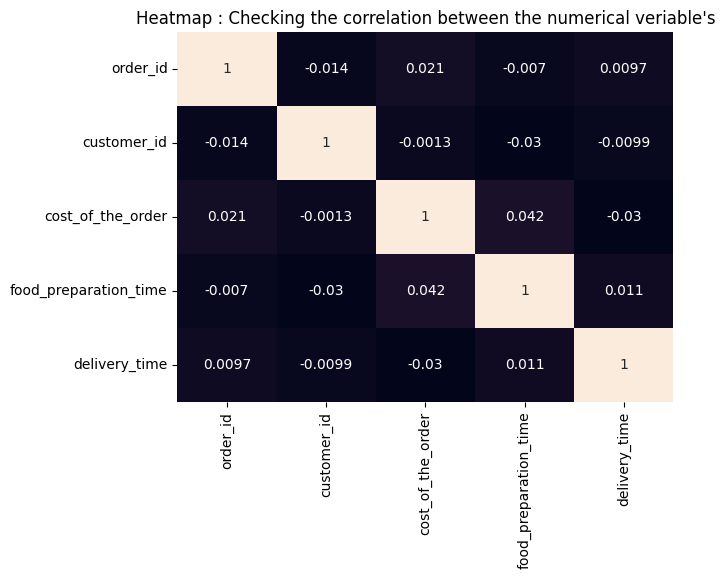

In [ ]:
plt.title("Heatmap : Checking the correlation between the numerical veriable's")
sns.heatmap(df[['order_id', 'customer_id', 'cost_of_the_order', 'food_preparation_time', 'delivery_time' ]].corr(), annot=True, cbar = False)

**Observation's:**

* From above chart, we can see there is no any strong relationship between all the variables.

* all values are close to the 0. Indicates no relationship between each other.

* Here we are not considering the order_id & customer_id because they both are not contributing any insights with other veriables.

* Cost of orders are very weak negative correlations with delivery time ( -0.03 value are near to zero ).

* Cost of orders are very weak postive correlation with food prepration time. ( 0.042 near to 0 )

* Food perp. time dosen't that much correlation with food delivery time.( 0.011 very weak positive correlation )

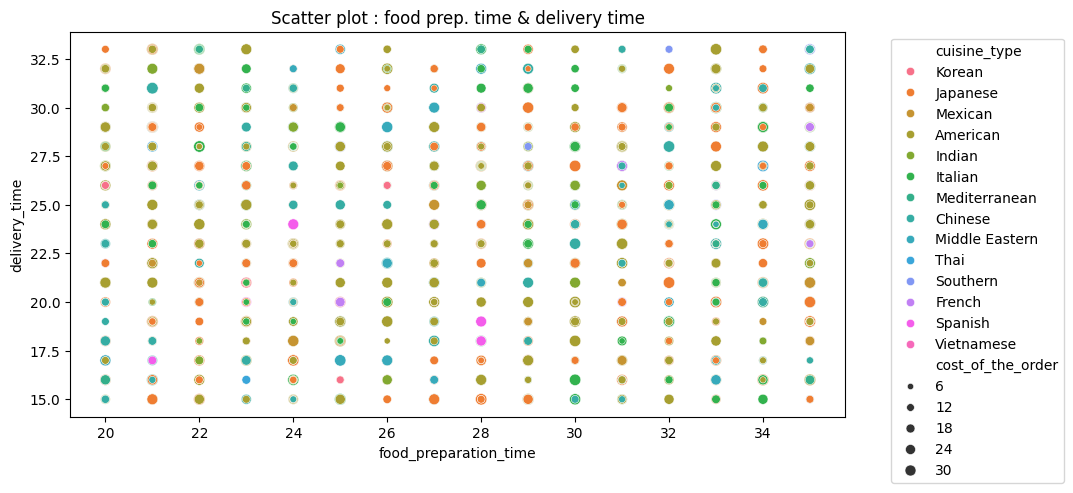

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Scatter plot : food prep. time & delivery time")
sns.scatterplot( data=df, x='food_preparation_time', y='delivery_time', size='cost_of_the_order', hue='cuisine_type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

**Observation's :**

* Here multi color bubles showing cuisine type & size of the bubble is depending on cost of food.

* There is no any correlation between the food prep. time & food delivery time with respect to cost of order.

* There is not any specific area where we can see the expensive orders have less prep. time & delivery time. some time expensive food took less time for food perp. & more time to delivery or vice-versa else both taking long time for food prep. & food delivery.

* Conclusion : The same pattern we already saw in heatmap above.

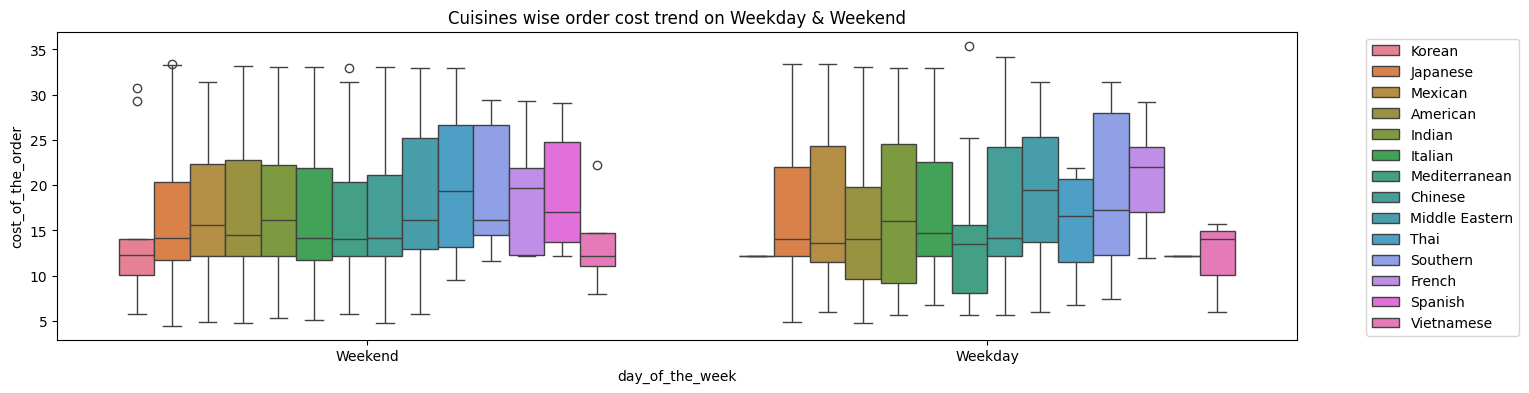

In [ ]:
plt.figure(figsize = (16, 4))
plt.title("Cuisines wise order cost trend on Weekday & Weekend")
sns.boxplot(data=df, x = 'day_of_the_week', y = 'cost_of_the_order', hue = 'cuisine_type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Observation's :**

* Above plot showing the costing of orders based on weekday & weekend trend.

* In weekend & weekday, we can see 75% of Korean & Vietnamese food's order cost is less than 14 dollars.

* Avg. food costing is <= 19 dollars for all food in weekend. Italian, Mediterranean, Chinese food avg. food costing are same on weekend & slightly differnce in Weekday avg. cost.

* Some outliers are present in both weekend & weekday.

* On Weekday some foods have started price from 5 dollar & it will goes till 30 or 31+ dollars. On weekday all food are cost start around 5 to 8 except French food.

* French food min. price start from 13 dollars on weekday also on weekend & max price is around 30 dollars. both the side median is left side skewed so mostly orders cost are right side which is <=22 dollars.

* food costing has much more variation on weekday than weekend from 25% to 75% orders except korean & vietnamese. This both korean & vietnamese food having much cost consistent with less variation.

* Italian food have good stability on order cost for both weekday & weekend.

* Mediterranean food cost having more variation on weekday & weekend.

* Spanish food more order cost on weekend as compaire to weekday.

* Indian food, 25% food order cost on weekday less than 10 dollars & on weekend less than 13 dollars. 75% of order cost <=21 in weekend & <=25 dollars on weekday.  

* **Conclusion :**
1) **Avg. food cost** is varies between **14-20 dollars** on weekday & weekend.
2) On **weekend orders cost varies between then 10-25 dollars** & on **weekday order cost varies between 8-27 dollars.**
3) Thai, Southern, French, Spanish, Vitenamese food minimum cost having more variation on weekend & weekday.
4) **Outliers** are present in data on weekend more than weekday.
5) Some cuisines are much consiste food costing on Weekend as compare to Weekday.


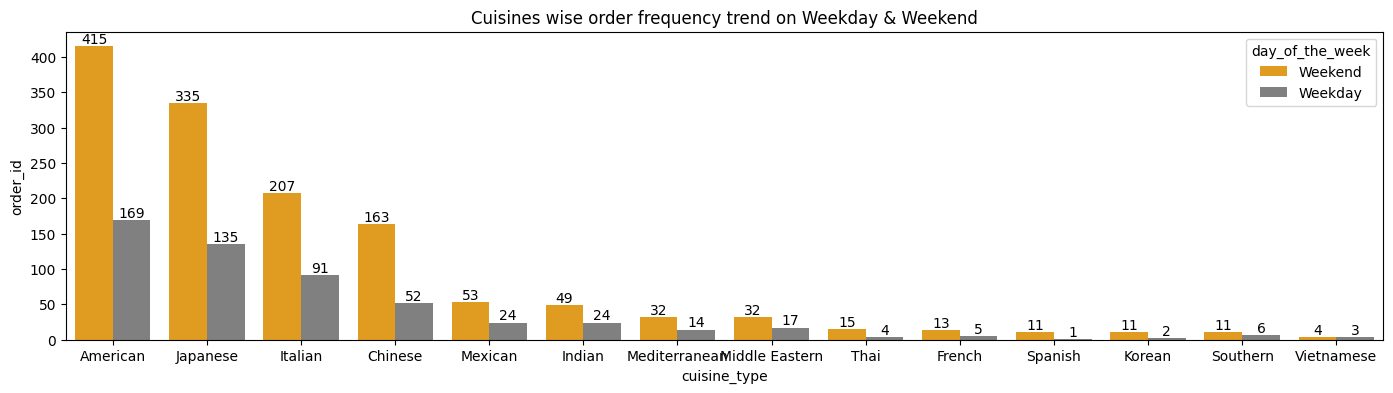

In [ ]:
# Creating a seprate df for order trend
order_trend = df.groupby(['cuisine_type','day_of_the_week'])['order_id'].count().sort_values(ascending=False).reset_index()
plt.figure(figsize=(17,4))
plt.title('Cuisines wise order frequency trend on Weekday & Weekend')
plot_6 = sns.barplot( data=order_trend, x='cuisine_type', y='order_id', hue='day_of_the_week', palette = ['orange', 'gray'])

for value in plot_6.containers :
  plot_6.bar_label(value)

plt.show()

**Observation's :**

* As per the above graph we can easily see, Weekend food order is more than weekday on every cuisines. except vietnamese. having less orders on both the sides.

* American, Japanese, Italian, Chinese Foods orders trend are more Weekend's and as well as weekday.

* Thai, French, Spanish, Korean, Southern, Vietnamese food are less order trend at both the sides (weekend & weekdays).

* If we buckting the cuisines according to order frequency then first bucket hold American, Japanese, Italian, Chinese whoes having more orders, 2nd buckets holds Mexican, Indian, Mediterranes, Middle Eastern, 3rd buckets holds the remaining cuisines whoes are less orders.

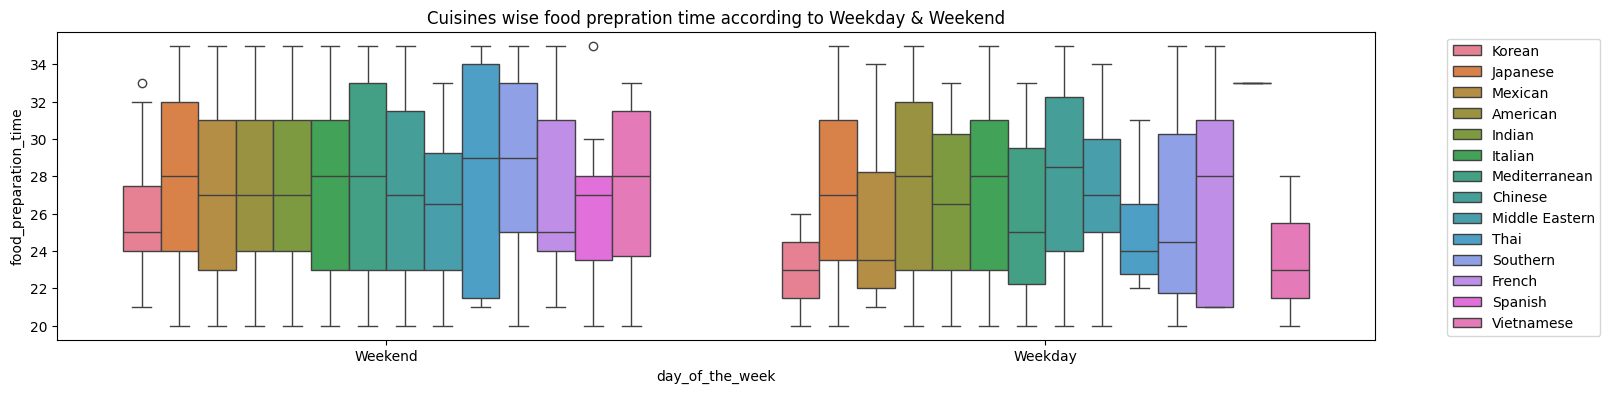

In [ ]:
plt.figure(figsize = (17, 4))
plt.title("Cuisines wise food prepration time according to Weekday & Weekend")
sns.boxplot(data=df, x = 'day_of_the_week', y = 'food_preparation_time', hue = 'cuisine_type' )
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Observation's :**

* Most of the cuisines food prep. time less variation on Weekend, but more fluctuation are happning in Weekday.

* In most of Cuisines takes Minimum time for food prep. 20 min in both the sides. ( Weekday & Weekend ) & Overall Food prepration time ranges between 20-35 min. from both weekday & weekend.

* Avg. food prep. time slightly varies in weekends but more fluctuation's in Weekdays.

* Thai, Chinese, mediterranean food take more time to prep. food on weekends

* Korean & Vietnamese cuisines more consistent to food prep. on weekdays.

* Spanish food prep. time is very consistent on weekdays around 33 min. but in Weekends it ranges from 20 min. to 30 min. & avg. time is 27.5 min. around on weekends.

* On weekends some cuisines takes much more time at max side than typical time it looks like some food takes more time at high demands periods.


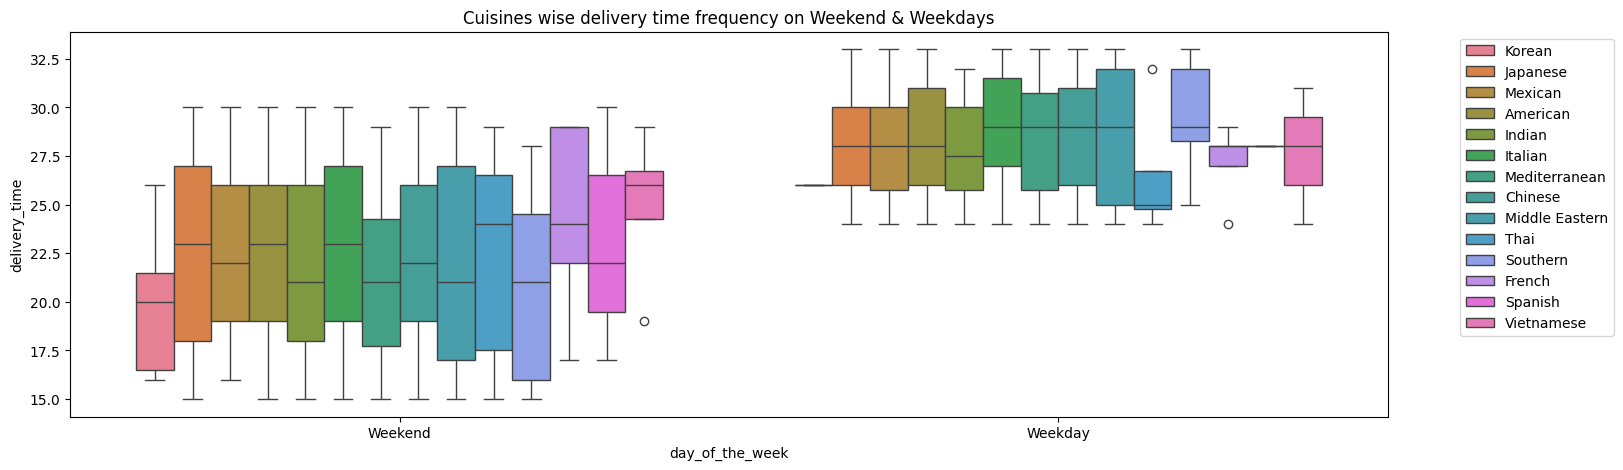

In [ ]:
plt.figure(figsize = (17, 5))
plt.title("Cuisines wise delivery time frequency on Weekend & Weekdays")
sns.boxplot(data=df, x = 'day_of_the_week', y = 'delivery_time', hue = 'cuisine_type')
plt.legend(bbox_to_anchor=(1.05, 1), loc = 'upper left')
plt.show()

**Observation's :**

* On weekend & weekday delivery time has more variation. delivery time very fluctuate between both side.

* In some of Cuisines having avg. delivery time ranges between 20-24 minute & on Weekday having avg. delivery time ranges between 27-30 minute.

* On weekend minimum delivery time start from 15 min. & maximum it goes around 30 minutes. On weekday minimum delivery time starts 24 min. & maximum goes around 32.5 minute.

* In some cuinies outliers are present in both the sides.

* On weekends most of the 75% orders are delivered between 15-28 minutes. on weekday most of the orders delivery time ranges between 25-31 minutes.

* Spanish & Korean cuisines has consistent delivery on weekdays.

* Delivery times vary more on weekends, indicating that higher demand may lead to longer delivery durations for some orders.

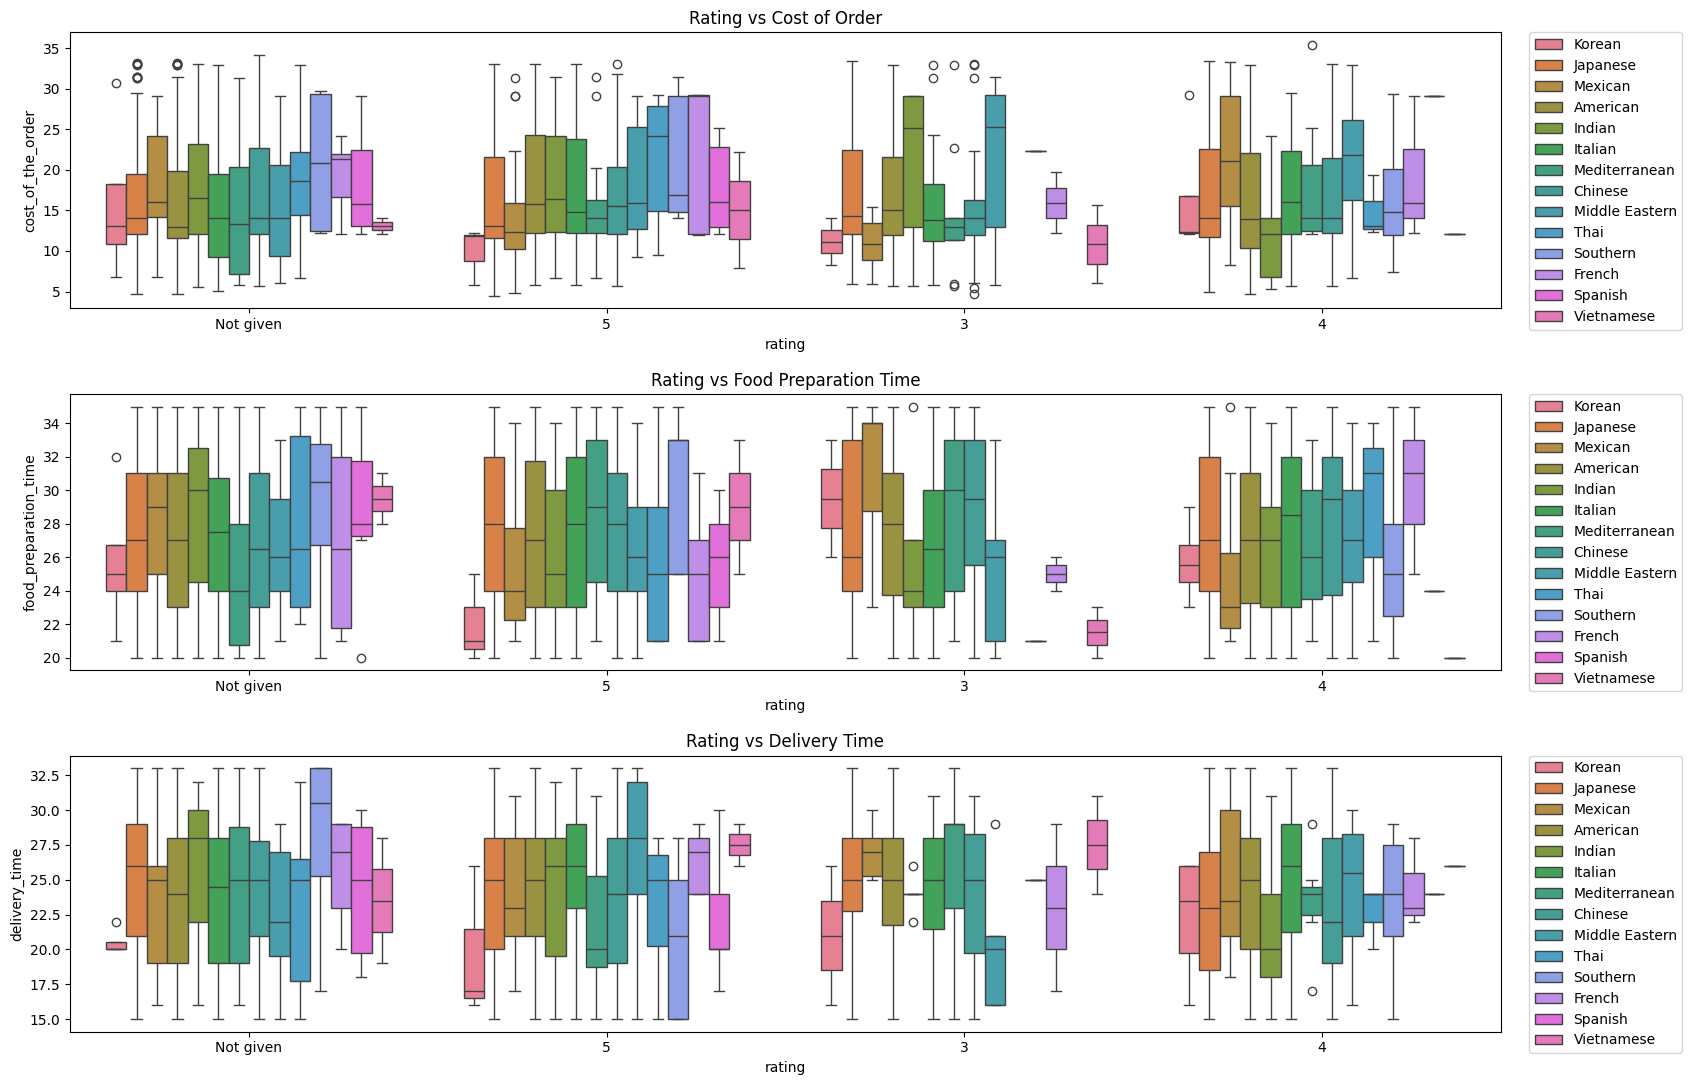

In [ ]:
plt.figure(figsize=(17,11))


plt.subplot(3,1,1)
sns.boxplot(data=df, x='rating', y='cost_of_the_order', hue='cuisine_type')
plt.title("Rating vs Cost of Order")
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', borderaxespad=0)


plt.subplot(3,1,2)
sns.boxplot(data=df, x='rating', y='food_preparation_time', hue='cuisine_type')
plt.title("Rating vs Food Preparation Time")
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', borderaxespad=0)


plt.subplot(3,1,3)
sns.boxplot(data=df, x='rating', y='delivery_time', hue='cuisine_type')
plt.title("Rating vs Delivery Time")
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

**Observation's :**

* From all the graphs we can't see any strong relation between then food-cost / food prepration time - rating / food delivery time - rating.

* Outliers are present in all the plots.

* **Cost of orders Vs rating :**

* In most of cuisines rating 5 & 4 meadin has more than 15 minutes. However, the difference is not very large, indicating price alone may not strongly drive ratings.

* **Food Prepration time vs. rating :**

* Most preparation times lie between 23–32 minutes for all ratings.

* Ratings 3, 4, and 5 have very similar preparation time distributions.

* There is no clear pattern showing that faster preparation leads to higher ratings.

* **Delivery Time Vs. rating :**

* Delivery times mostly range between 18–30 minutes.

* Lower ratings 3 show slightly more variability in delivery time.

* Higher ratings 4 and 5 tend to have less variability delivery times around 22–26 minutes.

In [ ]:
print("Cuisines Summary")
print() # used for gap
print() # used for gap

pivot_view = df.pivot_table( index = 'cuisine_type', columns = 'day_of_the_week', values = 'order_id', aggfunc = 'count', fill_value=0).reset_index()
pivot_view['Total Orders'] = pivot_view['Weekday'] + pivot_view['Weekend']
pivot_view['% Weekday Order Contribution'] = ((pivot_view['Weekday'] / pivot_view['Total Orders'] )*100).round(2)
pivot_view['% Weeked Order Contribution'] = ((pivot_view['Weekend'] / pivot_view['Total Orders'] )*100).round(2)
pivot_view['% Total Order Contribution'] = (pivot_view['Total Orders'] / (pivot_view['Total Orders'].sum()))*100
pivot_view['Rank (On total Orders)'] = pivot_view['% Total Order Contribution'].rank(method = 'dense', ascending= False)
pivot_view = pivot_view[['cuisine_type','Weekday', '% Weekday Order Contribution', 'Weekend', '% Weeked Order Contribution', 'Total Orders', '% Total Order Contribution', 'Rank (On total Orders)']].sort_values(by = 'Rank (On total Orders)', ascending = True)
pivot_view.columns = ['cuisine_type','Weekday', '% Weekday Order Contribution', 'Weekend', '% Weeked Order Contribution', 'Total Orders', '% Total Order Contribution', 'Rank (On total Orders)']
pivot_view.reset_index(drop=True)


Cuisines Summary




,cuisine_type,Weekday,% Weekday Order Contribution,Weekend,% Weeked Order Contribution,Total Orders,% Total Order Contribution,Rank (On total Orders)
0,American,169,28.94,415,71.06,584,30.77,1.00
1,Japanese,135,28.72,335,71.28,470,24.76,2.00
2,Italian,91,30.54,207,69.46,298,15.70,3.00
3,Chinese,52,24.19,163,75.81,215,11.33,4.00
4,Mexican,24,31.17,53,68.83,77,4.06,5.00
5,Indian,24,32.88,49,67.12,73,3.85,6.00
6,Middle Eastern,17,34.69,32,65.31,49,2.58,7.00
7,Mediterranean,14,30.43,32,69.57,46,2.42,8.00
8,Thai,4,21.05,15,78.95,19,1.00,9.00
9,French,5,27.78,13,72.22,18,0.95,10.00


**Observation's :**

* American cuisines are more contributing in orders. Most of the customers are like to order food from American cuisins. ( Contributing 30% on overall orders )

* Followed by Japanese food cuisines are on 2nd postion in % Contributions.

* Thai, French, Southern, Korean, Spanish, Vietnamese Cusines are very low contribution in orders. It seems like less people are like to order those foods.

* Top 5 Cuisines are American, Japanese, Italian, Chinese, Mexican. Except Mexican, remaining Cuisines are more contributing in food orders relatively high.

* A higher number of orders are placed on weekends compared to weekdays. Therefore, offering attractive discounts and promotional offers on weekdays could encourage more customers to place orders and help increase weekday revenue.

* Additionally, introducing combo deals or cashback offers at specific order value thresholds could help attract more customers and improve customer retention.

In [ ]:
top_10_resto = df.groupby(['restaurant_name']).agg(
    total_orders = ('order_id', 'count'),
    min_food_prep_time = ('food_preparation_time', 'min'),
    max_food_prep_time = ('food_preparation_time', 'max'),
    avg_food_prep_time = ('food_preparation_time', 'mean'),
    min_delivery_time = ('delivery_time', 'min'),
    max_delivery_time = ('delivery_time', 'max'),
    avg_delivery_time = ('delivery_time', 'mean')
).reset_index()

top_10_resto = top_10_resto.sort_values(by = 'total_orders', ascending= False).reset_index(drop=True).head(10)


bottom_10_resto = df.groupby(['restaurant_name']).agg(
    total_orders = ('order_id', 'count'),
    min_food_prep_time = ('food_preparation_time', 'min'),
    max_food_prep_time = ('food_preparation_time', 'max'),
    avg_food_prep_time = ('food_preparation_time', 'mean'),
    min_delivery_time = ('delivery_time', 'min'),
    max_delivery_time = ('delivery_time', 'max'),
    avg_delivery_time = ('delivery_time', 'mean')
).reset_index()

bottom_10_resto = bottom_10_resto[bottom_10_resto['total_orders'] > 10].sort_values(by = 'total_orders', ascending= True).reset_index(drop=True).head(10)

display("TOP 10 Restaurant's")
print()
display(top_10_resto)
print()
display("Bottom 10 Restaurant's")
print()
display(bottom_10_resto)

"TOP 10 Restaurant's"

,restaurant_name,total_orders,min_food_prep_time,max_food_prep_time,avg_food_prep_time,min_delivery_time,max_delivery_time,avg_delivery_time
0,Shake Shack,219,20,35,27.95,15,33,24.66
1,The Meatball Shop,132,20,35,27.18,15,33,24.24
2,Blue Ribbon Sushi,119,20,35,27.92,15,33,23.94
3,Blue Ribbon Fried Chicken,96,20,35,27.20,15,33,24.15
4,Parm,68,20,35,27.31,15,33,25.50
5,RedFarm Broadway,59,20,35,27.59,15,33,23.15
6,RedFarm Hudson,55,20,35,27.16,15,33,24.20
7,TAO,49,20,35,26.78,16,33,23.16
8,Han Dynasty,46,20,35,27.41,15,32,23.15
9,Blue Ribbon Sushi Bar & Grill,44,20,34,26.30,15,32,23.41


"Bottom 10 Restaurant's"

,restaurant_name,total_orders,min_food_prep_time,max_food_prep_time,avg_food_prep_time,min_delivery_time,max_delivery_time,avg_delivery_time
0,Melt Shop,11,21,30,27.64,16,33,23.45
1,Sushi Samba,11,21,35,29.09,16,32,24.64
2,Otto Enoteca Pizzeria,12,21,35,29.00,15,30,22.92
3,Burger Joint,12,20,35,27.50,15,33,23.08
4,S'MAC,12,20,34,29.42,17,32,24.75
5,Empanada Mama (closed),13,21,35,26.62,18,32,23.85
6,Vanessa's Dumplings,13,20,33,26.54,17,33,23.69
7,Osteria Morini,14,22,34,27.43,16,33,24.79
8,Hill Country Fried Chicken,14,20,35,27.36,15,33,22.64
9,J. G. Melon,15,20,35,28.47,15,33,25.00


**Observation's :**

**Top 10 Performing Restaurants :**
* In top performing restaurants has food prep. time ranges 20-35 minutes. On an average prep. food within 27 minutes.

* Food delivery time ranges between 15-33 minutes. On an average it takes 24 minutes to deliver food.

**Bottom 10 Performing Restaurants :**
* I filtered restaurants with more than 10 orders to avoid analyzing restaurants with very small sample sizes. Low-order restaurants can distort performance metrics, so this threshold ensures the analysis reflects consistent performance trends rather than random noise.

* In bottom performing restaurants has food prep. time ranges 20-35 minutes. some time is slightly varies. On an average it takes 27 minutes to prepare food.

* Food delivery time ranges between 15-33 minutes. On an average it takes 24 minutes to deliver food.

**Conclusion :**    
* Based on the analysis, there is no significant indication that orders are influenced by time-related factors.

#### **Q13. The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.**

In [ ]:
# Need to change the data type of rating column because rating column has on string datatype.

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df_view = df.groupby('restaurant_name').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

filter_view = df_view[ (df_view['rating_count'] > 50) & (df_view['avg_rating'] > 4) ].reset_index(drop=True).sort_values(by = ['rating_count'], ascending = False)
filter_view

,restaurant_name,rating_count,avg_rating
2,Shake Shack,133,4.28
3,The Meatball Shop,84,4.51
1,Blue Ribbon Sushi,73,4.22
0,Blue Ribbon Fried Chicken,64,4.33


**Observation's :**

* There are 4 restaurants whoes meet this criterion.

#### **Q.14 The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.**

In [ ]:

df['Charges'] = df['cost_of_the_order'].apply(lambda x : x * 0.25 if x > 20 else ( x * 0.15 if x > 5 else x))

f"Net Revenue Genrated by company : {df['Charges'].sum().round(2)} accross all orders."

'Net Revenue Genrated by company : 6209.04 accross all orders.'

**Observation's :**

* Based on the commission structure 15% for orders above order cost 5 and 25% for orders above order cost 20 the company generated a total net revenue of 6,209.04 dollars.

#### **Q15. The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)**

In [ ]:
df['Total Time'] = df['food_preparation_time'] + df['delivery_time']
orders_more_than_60_minutes_percent = ( ((df['Total Time']>60).sum()/ df.shape[0])*100 ).round(2)
f"percentage of orders take more than 60 minutes to get delivered from the time the order is placed : {orders_more_than_60_minutes_percent}%"

'percentage of orders take more than 60 minutes to get delivered from the time the order is placed : 10.54%'

**Observation's :**

* **10.54%** of the total orders have a delivery time greater than 60 minutes.

#### **Q16. The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?**

In [ ]:
delivery_stat_view = df.groupby(['day_of_the_week']).agg(
    min_delivery_time = ('delivery_time', 'min'),
    max_delivery_time = ('delivery_time', 'max'),
    avg_delivery_time = ('delivery_time', 'mean'),
    std = ('delivery_time', 'std')
).reset_index()

delivery_stat_view['cv'] = ((delivery_stat_view['std'] / delivery_stat_view['avg_delivery_time'] )*100).round(2)
delivery_stat_view

,day_of_the_week,min_delivery_time,max_delivery_time,avg_delivery_time,std,cv
0,Weekday,24,33,28.34,2.89,10.20
1,Weekend,15,30,22.47,4.63,20.60


**Observation's :**

* From above stats view we can see, on Weekday delivery time ranges between 24-33 minutes. On Weekend delivery time ranges between 15-30 min.

* On Weekend food delivery time is significantly lower (~6 minutes faster ) than weekdays delivery.

* If we observe CV, On weekdays (cv, 10.20) food dalivery time variations has low. much more stable delivery time, but on Weekends cv is 20.60 almost double than weekdays so more variation occuers on weekends. due to fluctuating demand or potiential load during peak periods.

* **CV = ( standard deviation / mean ) x 100**

if cv < 10% then low variation ( more consistent data )
, if cv between 10% - 20% then moderate variation ( acceptable data )
, if cv > 20% then high variation ( data highly spread / incosistent data)

# **Conclusion and Recommendations**

#### **Q17. What are your conclusions from the analysis? What recommendations would you like to share to help improve the business?**

### **Conclusion's & Recommendation's :**

**(I) Demand & Supply Trend on Weekdays & Weekends :**  

* Orders valume is more on weekends compared to weekdays.
* Weekend represent then pick demand periods for restaurant's as well as delivery partners.
* So we have to ensure restaurant order capacity, and delivery partners availability during weekends to handle higher demands efficiently.

**(II) Correlation between then operational variables :**

* As per the analysis there is no strong correlation betweeen the variables such as food cost, food prepration time, food delivery time, rating.

* It's looking like order volume is driven by other factors such as customer preference, cuisines popularity.

* So we have to work on some additional factores such as discounts, marketing campaigns, restaurant visibility & popularity.

**(III) Low performing Cuisines :**

* Some cuisine types receive significantly fewer orders compared to others.

* This cuisines types may be experiencing lower visibility or week customer demands. or any regional/geolocation issues.

* so we have to work on targeted promotions, discounts, or some offers to increase visibility and demand for low performing cuisines.

**(IV) Correlation between rating & operational metrics :**

* Customer ratings do not show strong relationships with factors such as restaurant, food delivery time, food preparation time, or food order cost.

* This indicates that customer satisfaction may depend on other selective factors such as food quality, food packaging, or food service experience.

* So we have to focus on collecting detailed customer feedback to identify specific areas of improvement beyond operational metrics.

**(V) Delivery Time Optimization During Peak Periods :**

* Delivery times tend to vary more during high demand periods.

* Operational efficiency during peak hours can directly influence customer satisfaction.

* So we have to work on optimizing delivery logistics during peak periods, such as improving delivery partner allocation, optimizing delivery routes, or increasing delivery partner availability.